This notebook is a minimal reproducible calibration demo

Current dataset uses IMDB as a placeholder to validate the pipeline; Alzheimer-specific speech datasets will be integrated subject to access approval.

In [2]:
!pip -q install transformers datasets accelerate scikit-learn matplotlib
!pip -q install torch torchvision torchaudio

In [4]:
# Train model using distilroberta-base and AutomodelForSequenceClassification.
# As I cannot get access for AD dataset, here I just use some other dataset as placeholder, and can be replaced with AD dataset later.

import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

model_name = "distilroberta-base"  # Fast training, can switch to roberta-base
dataset = load_dataset("imdb")

# take a small sample to run to use to check whole idea of calibration
train_ds = dataset["train"].shuffle(seed=42).select(range(4000))
val_ds   = dataset["test"].shuffle(seed=42).select(range(2000))

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok   = val_ds.map(tokenize_fn, batched=True)

cols = ["input_ids", "attention_mask", "label"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "acc": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

args = TrainingArguments(
    output_dir="./out",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()
metrics = trainer.evaluate()
print(metrics)

# find calibration set for logits + labels
pred = trainer.predict(val_tok)
logits = pred.predictions
labels = pred.label_ids

np.save("val_logits.npy", logits)
np.save("val_labels.npy", labels)

print("Saved:", logits.shape, labels.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Acc,F1
1,0.312858,0.262910,0.888000,0.889219


{'eval_loss': 0.26290974020957947, 'eval_acc': 0.888, 'eval_f1': 0.8892185954500494, 'eval_runtime': 14.4003, 'eval_samples_per_second': 138.886, 'eval_steps_per_second': 4.375, 'epoch': 1.0}
Saved: (2000, 2) (2000,)


In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

logits = np.load("val_logits.npy")
labels = np.load("val_labels.npy")

logits_t = torch.tensor(logits, dtype=torch.float32)
labels_t = torch.tensor(labels, dtype=torch.long)

def softmax_probs(logits_):
    return torch.softmax(logits_, dim=1)

def expected_calibration_error(probs, labels, n_bins=15):
    confidences, predictions = torch.max(probs, dim=1)
    accuracies = predictions.eq(labels)

    ece = torch.zeros(1)
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i+1]
        in_bin = (confidences > lo) & (confidences <= hi)
        prop = in_bin.float().mean()
        if prop.item() > 0:
            acc = accuracies[in_bin].float().mean()
            conf = confidences[in_bin].mean()
            ece += torch.abs(conf - acc) * prop
    return ece.item()

class TempScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_T = nn.Parameter(torch.zeros(1))  # T = exp(log_T)

    def forward(self, logits_):
        T = torch.exp(self.log_T)
        return logits_ / T

scaler = TempScaler()
criterion = nn.CrossEntropyLoss()
opt = optim.LBFGS(scaler.parameters(), lr=0.1, max_iter=50)

def closure():
    opt.zero_grad()
    loss = criterion(scaler(logits_t), labels_t)
    loss.backward()
    return loss

opt.step(closure)
T = torch.exp(scaler.log_T).item()

probs_before = softmax_probs(logits_t)
probs_after  = softmax_probs(scaler(logits_t))

ece_before = expected_calibration_error(probs_before, labels_t)
ece_after  = expected_calibration_error(probs_after, labels_t)

print("Learned temperature T =", T)
print("ECE before:", ece_before)
print("ECE after :", ece_after)

Learned temperature T = 1.1160390377044678
ECE before: 0.033638641238212585
ECE after : 0.035115309059619904


In [7]:
#ECE results above are not expected, it may due to bin number sensitivity of ECE, check nll.
import torch.nn.functional as F
nll_before = F.cross_entropy(logits_t, labels_t).item()
nll_after  = F.cross_entropy(scaler(logits_t), labels_t).item()
print(nll_before, nll_after)

0.2629097104072571 0.2608325183391571


In [9]:
# Sensitivity of ECE on bin number.
for b in [5,10,15,20,30,50]:
    eb = expected_calibration_error(torch.softmax(logits_t,1), labels_t, n_bins=b)
    ea = expected_calibration_error(torch.softmax(scaler(logits_t),1), labels_t, n_bins=b)
    print(b, eb, ea, "delta", ea-eb)

5 0.02941705472767353 0.015818709507584572 delta -0.013598345220088959
10 0.029416993260383606 0.027642514556646347 delta -0.001774478703737259
15 0.033638641238212585 0.035115309059619904 delta 0.0014766678214073181
20 0.03474551811814308 0.03773285821080208 delta 0.0029873400926589966
30 0.04598156362771988 0.036676641553640366 delta -0.009304922074079514
50 0.0458231158554554 0.04112056642770767 delta -0.0047025494277477264


While temperature scaling consistently reduced the negative log-likelihood, the impact on ECE varied across bin configurations, highlighting the sensitivity of histogram-based calibration metrics.

In [10]:
#Brier
import torch
import torch.nn.functional as F

probs_before = F.softmax(logits_t, dim=1)
probs_after  = F.softmax(scaler(logits_t), dim=1)

y_onehot = F.one_hot(labels_t, num_classes=2).float()

brier_before = torch.mean(torch.sum((probs_before - y_onehot)**2, dim=1)).item()
brier_after  = torch.mean(torch.sum((probs_after - y_onehot)**2, dim=1)).item()

print("Brier before:", brier_before)
print("Brier after :", brier_after)

Brier before: 0.16093511879444122
Brier after : 0.1587461531162262


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def plot_reliability_diagram(probs, labels, n_bins=15, title="Reliability Diagram"):
    probs = probs.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()

    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == labels

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(confidences, bins) - 1

    bin_acc = []
    bin_conf = []

    for i in range(n_bins):
        mask = bin_ids == i
        if np.sum(mask) > 0:
            bin_acc.append(np.mean(accuracies[mask]))
            bin_conf.append(np.mean(confidences[mask]))
        else:
            bin_acc.append(0)
            bin_conf.append(0)

    plt.figure()
    plt.plot([0, 1], [0, 1])
    plt.bar(bin_conf, bin_acc, width=1/n_bins)
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.show()

In [12]:
probs_before = F.softmax(logits_t, dim=1)
probs_after = F.softmax(scaler(logits_t), dim=1)

<Figure size 640x480 with 0 Axes>

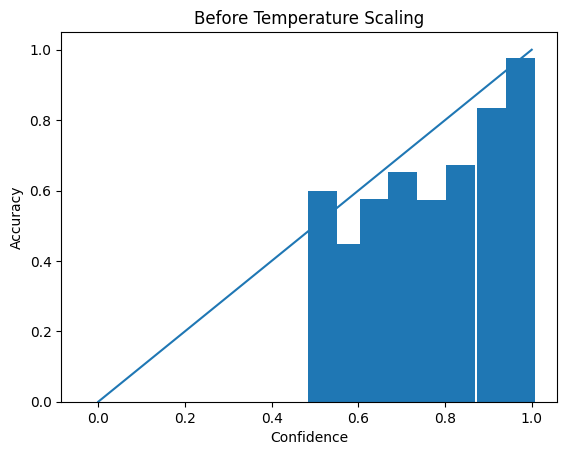

In [18]:
plt.savefig("reliability_before.png", dpi=200, bbox_inches="tight")
plot_reliability_diagram(probs_before, labels_t, title="Before Temperature Scaling")


<Figure size 640x480 with 0 Axes>

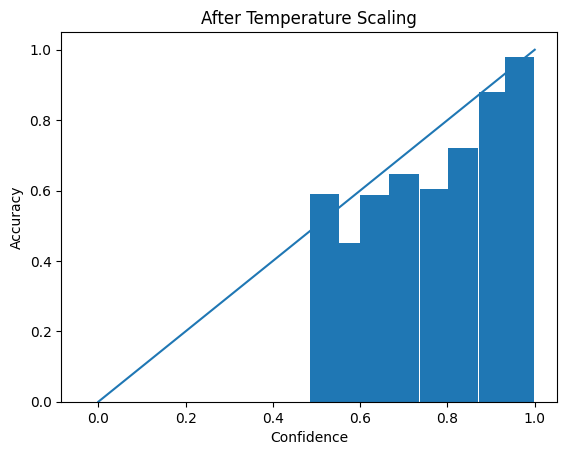

In [17]:
plt.savefig("reliability_after.png", dpi=200, bbox_inches="tight")
plot_reliability_diagram(probs_after, labels_t, title="After Temperature Scaling")